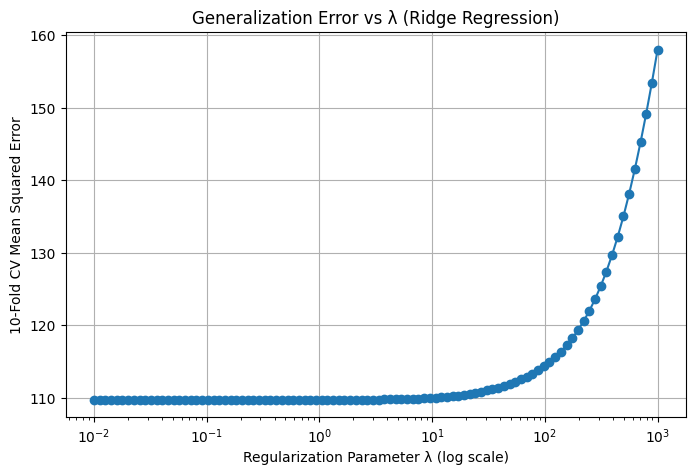

Best λ: 1.484968262254465
Cement (component 1)(kg in a m^3 mixture) : 12.2531
Blast Furnace Slag (component 2)(kg in a m^3 mixture) : 8.7024
Fly Ash (component 3)(kg in a m^3 mixture) : 5.3995
Water  (component 4)(kg in a m^3 mixture) : -3.3806
Superplasticizer (component 5)(kg in a m^3 mixture) : 1.7393
Coarse Aggregate  (component 6)(kg in a m^3 mixture) : 1.2260
Fine Aggregate (component 7)(kg in a m^3 mixture) : 1.3886
Age (day)                 : 7.1897


In [1]:
import argparse
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

df = pd.read_excel("Concrete_Data.xls")

X = df.iloc[:, :-1]   # all columns except the last one
y = df.iloc[:, -1]    # the last column (strength)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lambdas = np.logspace(-2, 3, 100)  # λ values from 10^-4 to 10^3
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mse_scores = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    neg_mse = cross_val_score(ridge, X_scaled, y,
                              cv=kf, scoring='neg_mean_squared_error')
    mse_scores.append(-neg_mse.mean())



plt.figure(figsize=(8,5))
plt.semilogx(lambdas, mse_scores, marker='o')
plt.xlabel("Regularization Parameter λ (log scale)")
plt.ylabel("10-Fold CV Mean Squared Error")
plt.title("Generalization Error vs λ (Ridge Regression)")
plt.grid(True)
plt.show()

best_lambda = lambdas[np.argmin(mse_scores)]
print("Best λ:", best_lambda)

ridge_final = Ridge(alpha=best_lambda)
ridge_final.fit(X_scaled, y)

coef = ridge_final.coef_
for name, value in zip(X.columns, coef):
    print(f"{name:25s} : {value:.4f}")




=== Two-level CV Results (per outer fold) ===
   fold  lambda_star  ridge_test_MSE  h_star  ann_test_MSE  baseline_test_MSE  \
0     1       1.2690        101.2124      32       34.5017           268.4751   
1     2       1.2690         86.2918      32       42.9058           247.7175   
2     3       0.7279        135.5595      32       37.2655           299.1124   
3     4       1.2690        133.5608      32       33.6044           371.8553   
4     5       2.2122        142.4965      16       48.7842           263.1545   
5     6       1.2690        108.8234      32       20.0070           304.3707   
6     7       2.2122         90.1270      32       26.8696           302.5810   
7     8       0.4175         89.3473      32       21.7154           261.7986   
8     9       0.2395        105.1621      32       27.3498           244.9080   
9    10       0.0001        105.7006      32       25.9210           227.3508   

   ridge_test_RMSE  ann_test_RMSE  baseline_test_RMSE  
0    